In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

import sys
sys.path.append('../src/kidney')
import _timeseries_to_csv_oz as tsc
import plotting_oz as pz


## EMPA

In [4]:
da = xr.open_datatree('../data/raw/time_series_empa.nc')
# da = xr.open_datatree('../data/raw/time_series_vehicle_coarse.nc') # Vehicle

In [117]:
bfi = tsc.make_table_with_bfi_response(da)
bp = tsc.make_table_with_bp_response(da, time_stages=tsc.TIME_STGAES_BFI) #
power = tsc.make_table_with_power_response(da)
freq = tsc.make_table_with_frequency_response(da)

In [138]:
bfi.head()

stage,rat,age,sex,gtyp,treatment,vessel,activity_type,baseline,response,change,change_rel
0,20240813a,young,M,fa/fa,empa,0,subthreshold,51.383179,45.819920,-5.563259,-0.108270
2,20240813a,young,M,fa/fa,empa,1,subthreshold,48.439644,43.961040,-4.478603,-0.092457
4,20240813a,young,M,fa/fa,empa,2,subthreshold,48.661846,43.946270,-4.715576,-0.096905
6,20240813a,young,M,fa/fa,empa,3,subthreshold,56.596111,52.126743,-4.469368,-0.078970
8,20240813a,young,M,fa/fa,empa,4,subthreshold,55.997871,51.108822,-4.889050,-0.087308


In [119]:
power['age'] = power.age.str.lower()
bfi['age'] = bfi.age.str.lower()
freq['age'] = freq.age.str.lower()
bp['age'] = bp.age.str.lower()

# Plot data

## Power

In [11]:
power['baseline_log'] = np.log10(power['baseline'])

f, axs = plt.subplots(1,2,figsize=(14,2), sharey=True)
jitter=0.08
shift=0.3
for axi in axs:
    axi.axhline(ls='--', color='k')
for (bnd, pp), ax in zip(power.groupby('band'), axs):

    xlabels = []
    xticks = []
    for i, (rat, grp) in enumerate(pp.groupby('rat')):
        y = grp['baseline_log'].values
        # y = np.log10(grp['pow_baseline'].values)
        x = i + jitter*np.random.randn(y.size)
        p = ax.plot(x,y, ls='', marker='.')
        xlabels.append(rat)
        xticks.append(i+shift/2)
    ax.set_xticks(xticks, xlabels, rotation=90)


axs[0].set(ylabel='Log10[ Norm. Power ]', title='Baseline: Canonical band', xlabel='Rats (random order)')
axs[1].set(title='Baseline: Low frequency band', xlabel='Rats (random order)')


NameError: name 'power' is not defined

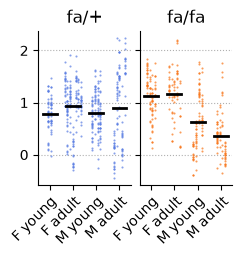

In [126]:
sele = (power.activity_type!='double')&(power.band=='canonical')
pz.plot_panel(power[sele], 'baseline_log');

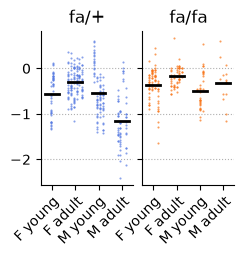

In [128]:
sele = (power.activity_type=='single')&(power.band=='canonical')
pz.plot_panel(power[sele], 'change_log');

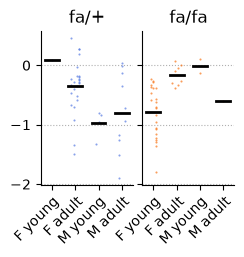

In [130]:
sele = (power.activity_type=='double')&(power.band=='canonical')
pz.plot_panel(power[sele], 'change_log');

## Mean BFI

[Text(0, 0.5, 'Mean BFI'),
 Text(0.5, 1.0, 'Baseline: Canonical band'),
 Text(0.5, 0, 'Rat #')]

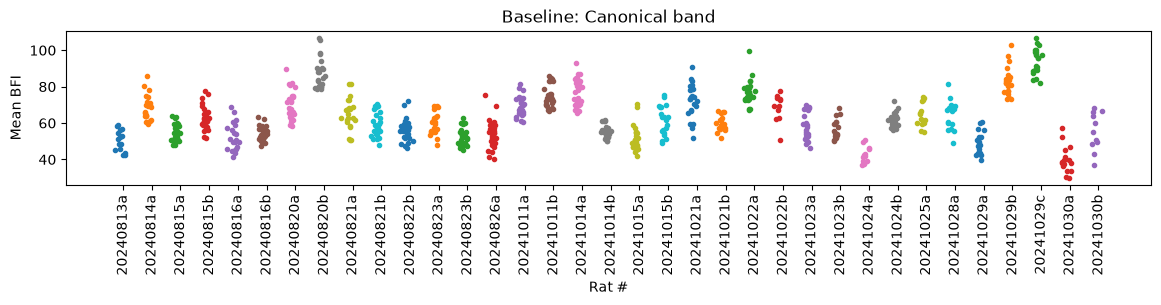

In [93]:
f, ax = plt.subplots(figsize=(14,2), sharey=True)
jitter=0.08
shift=0.3


xlabels = []
xticks = []
for i, (rat, grp) in enumerate(bfi.groupby('rat')):
    y = grp['baseline'].values
    # y = np.log10(grp['pow_baseline'].values)
    x = i + jitter*np.random.randn(y.size)
    p = ax.plot(x,y, ls='', marker='.')
    xlabels.append(rat)
    xticks.append(i+shift/2)
ax.set_xticks(xticks, xlabels, rotation=90)
ax.set(ylabel='Mean BFI', title='Baseline: Canonical band', xlabel='Rat #')

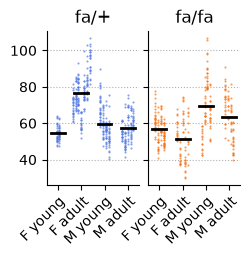

In [95]:

# sele = (bfi.treatment=='empa')
pz/plot_panel(bfi, 'baseline');
# plt.savefig('figures/power_bsl_canon.pdf', dpi=600, bbox_inches='tight', transparent=True)

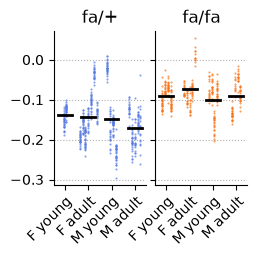

In [97]:
pz/plot_panel(bfi, 'change_rel');
# plt.savefig('figures/power_bsl_canon.pdf', dpi=600, bbox_inches='tight', transparent=True)

## Frequency

[Text(0.5, 1.0, 'Baseline: Low frequency band'),
 Text(0.5, 0, 'Rats (random order)')]

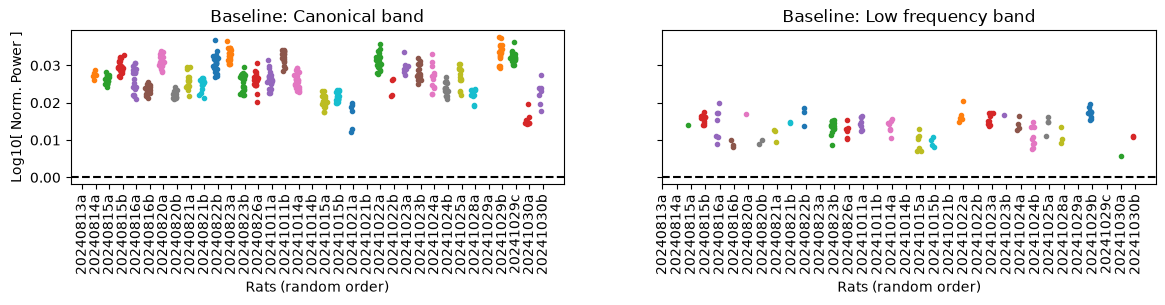

In [99]:
f, axs = plt.subplots(1,2,figsize=(14,2), sharey=True)
jitter=0.08
shift=0.3
for axi in axs:
    axi.axhline(ls='--', color='k')
for (bnd, pp), ax in zip(freq.groupby('band'), axs):

    xlabels = []
    xticks = []
    for i, (rat, grp) in enumerate(pp.groupby('rat')):
        y = grp['baseline'].values
        # y = np.log10(grp['pow_baseline'].values)
        x = i + jitter*np.random.randn(y.size)
        p = ax.plot(x,y, ls='', marker='.')
        xlabels.append(rat)
        xticks.append(i+shift/2)
    ax.set_xticks(xticks, xlabels, rotation=90)


axs[0].set(ylabel='Log10[ Norm. Power ]', title='Baseline: Canonical band', xlabel='Rats (random order)')
axs[1].set(title='Baseline: Low frequency band', xlabel='Rats (random order)')


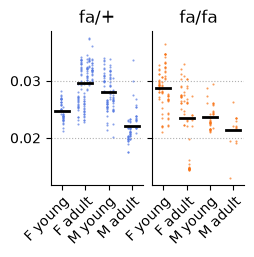

In [101]:

sele = (freq.activity_type=='single')&(freq.band=='canonical')
pz/plot_panel(freq[sele], 'baseline');
# plt.savefig('figures/power_bsl_canon.pdf', dpi=600, bbox_inches='tight', transparent=True)

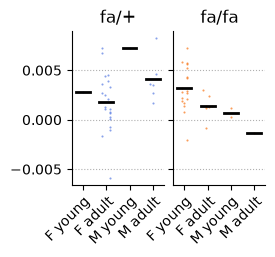

In [103]:

sele = (freq.activity_type=='double')&(freq.band=='canonical')
pz/plot_panel(freq[sele], 'change');
# plt.savefig('figures/power_bsl_canon.pdf', dpi=600, bbox_inches='tight', transparent=True)

## Mean Blood pressure

[Text(0, 0.5, 'Blood pressure (mmHg)'),
 Text(0.5, 1.0, 'Baseline'),
 Text(0.5, 0, 'Rat #')]

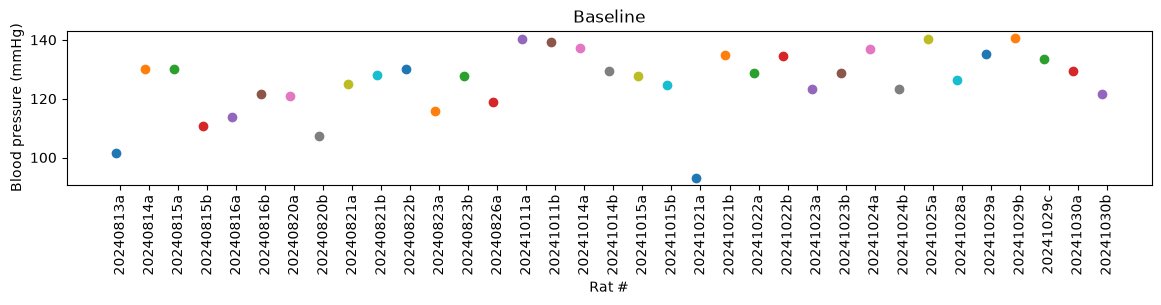

In [132]:
f, ax = plt.subplots(figsize=(14,2), sharey=True)
jitter=0.08
shift=0.3


xlabels = []
xticks = []
for i, (rat, grp) in enumerate(bp.groupby('rat')):
    y = grp['baseline']
    p = ax.plot(i, y, ls='', marker='o')
    xlabels.append(rat)
    xticks.append(i+shift/2)
ax.set_xticks(xticks, xlabels, rotation=90)
ax.set(ylabel='Blood pressure (mmHg)', title='Baseline', xlabel='Rat #')

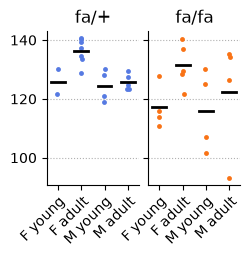

In [134]:
pz.plot_panel_one_val_per_rat(bp, 'baseline');

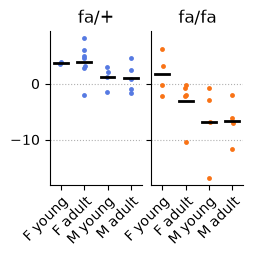

In [136]:
pz.plot_panel_one_val_per_rat(bp, 'change');